# Machine Learning Project - Premium with Lifestyle Risk

## Objective
The goal of this machine learning project is to predict **Insurance Premium**.

## Problem Type
This is a **Regression** problem.

## Important Considerations

- **Business Driven Feature** → `life_style_risk_score`
- **Evaluation Focus**:
  - Accuracy matters
  - Error percentage (business impact) is equally important

In [1]:
#Import all the necessary libraries required for this machine learning project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(f"All Libraries have been imported successfully")

All Libraries have been imported successfully


# Data Loading
### Objective : To Load the dataset onto a dataframe
The goal of this step is to load the dataset from the excel file named as `premiums_with_life_style.xlsx`

Once the data frame is loaded, we shall use **df.head()** to display the top few records of this dataset.

In [5]:
# Load the dataset onto a dataframe

# Install required package (run once)
!pip install openpyxl

# Import necessary library
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_excel('premiums_with_life_style.xlsx')

# Display the first 5 rows
df.head()

,Age,Gender,Region,Marital_status,Physical_Activity,Stress_Level,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


# Initial Data Inspection

Before any actual EDA or feature engineering is done, let's perform a complete inspection.

# 1. Dataset Dimensions

`df.shape`

**What it does:** Returns the dimensions of the DataFrame as (rows, columns)

**Why it is important:** Tells you how many samples (rows) and features (columns) you are working with

**Example output:** (5000, 12) meaning 5000 rows and 12 columns

# 2. Column Names

`df.columns`

**What it does:** Returns all column names in the dataset

**Why it is important:** Helps you understand what features are available for analysis

**Example output:** Index(['age', 'income', 'life_style_risk_score', 'premium'], dtype='object')

# 3. Data Types and Memory Usage

`df.info`

**What it does:** Provides a concise summary of the DataFrame including column names, non-null count, data types (int64, float64, object, etc.), and memory usage

**Why it is important:**
- Identifies which columns need data type conversion
- Reveals missing values at a glance
- Helps decide encoding strategies for categorical variables

# 4. Statistical Summary

`df.describe`

**What it does:** Generates descriptive statistics for numerical columns including count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum

**Why it is important:**
- Detects outliers from unusually min or max values
- Understands data distribution
- Identifies scaling requirements for machine learning models
- Reveals data range for each feature

# 5. Missing Values Count

`df.isnull().sum`

**What it does:** Counts the number of missing (NaN) values in each column

**Why it is important:**
- Determines which columns need imputation
- Helps decide between dropping versus filling missing values
- Impacts model performance if not handled properly

**Example output:** age: 0, income: 45, life_style_risk_score: 0, premium: 0

# 6. Duplicate Rows Count

`df.duplicated().sum`

**What it does:** Counts the total number of completely duplicate rows in the dataset

**Why it is important:**
- Duplicate data can bias model training
- May indicate data collection errors
- Removing duplicates prevents overfitting

**Example output:** 23 meaning 23 rows are exact duplicates of others

In [6]:
df.shape

(10000, 15)

In [7]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Physical_Activity',
       'Stress_Level', 'Number Of Dependants', 'BMI_Category',
       'Smoking_Status', 'Employment_Status', 'Income_Level', 'Income_Lakhs',
       'Medical History', 'Insurance_Plan', 'Annual_Premium_Amount'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Age                    10000 non-null  int64
 1   Gender                 10000 non-null  str  
 2   Region                 10000 non-null  str  
 3   Marital_status         10000 non-null  str  
 4   Physical_Activity      10000 non-null  str  
 5   Stress_Level           10000 non-null  str  
 6   Number Of Dependants   10000 non-null  int64
 7   BMI_Category           10000 non-null  str  
 8   Smoking_Status         9991 non-null   str  
 9   Employment_Status      9993 non-null   str  
 10  Income_Level           9982 non-null   str  
 11  Income_Lakhs           10000 non-null  int64
 12  Medical History        10000 non-null  str  
 13  Insurance_Plan         10000 non-null  str  
 14  Annual_Premium_Amount  10000 non-null  int64
dtypes: int64(4), str(11)
memory usage: 1.1 MB


In [9]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,41.316300,3.192900,23.339900,19505.063900
std,57.971661,21.650454,32.302974,8893.649171
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11777.750000
50%,37.000000,2.000000,16.000000,19312.000000
75%,50.000000,3.000000,31.000000,26494.500000
max,1178.000000,456.000000,960.000000,45854.000000


In [10]:
df.isnull().sum()

Age                       0
Gender                    0
Region                    0
Marital_status            0
Physical_Activity         0
Stress_Level              0
Number Of Dependants      0
BMI_Category              0
Smoking_Status            9
Employment_Status         7
Income_Level             18
Income_Lakhs              0
Medical History           0
Insurance_Plan            0
Annual_Premium_Amount     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis
### Univariate Analysis
Understand each column inidvidually. **Each column must be understood** so that the trend can be identified.

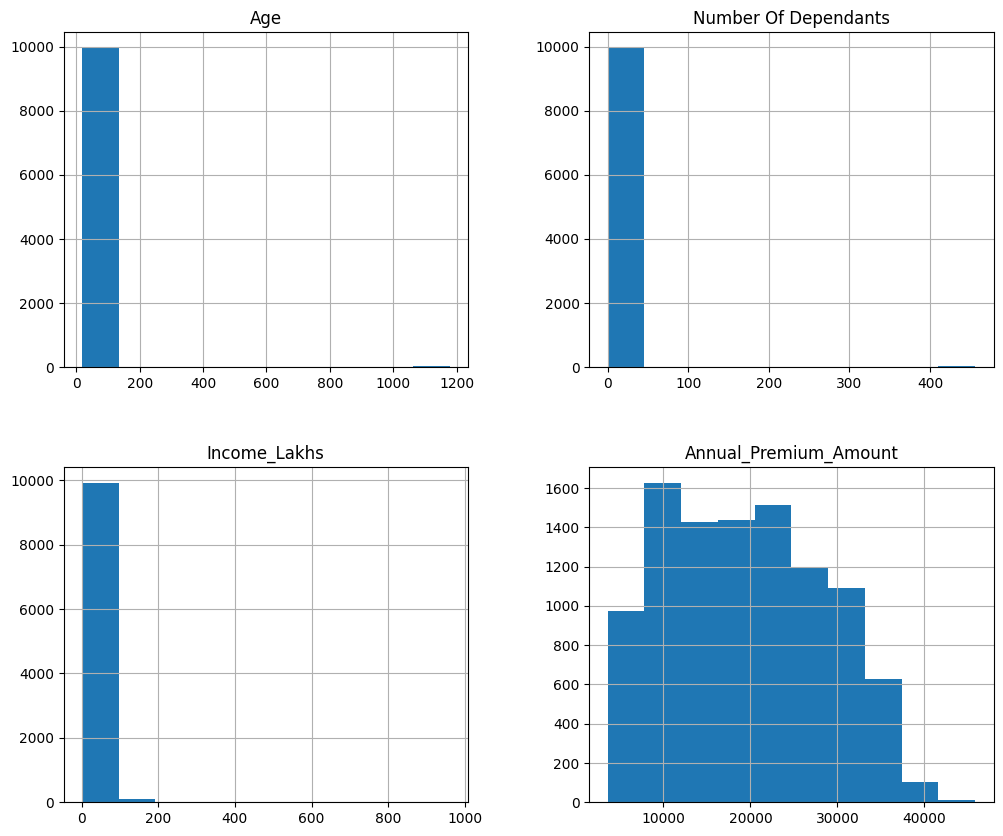

C:\Users\manan\AppData\Local\Temp\ipykernel_16964\944714210.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object'):


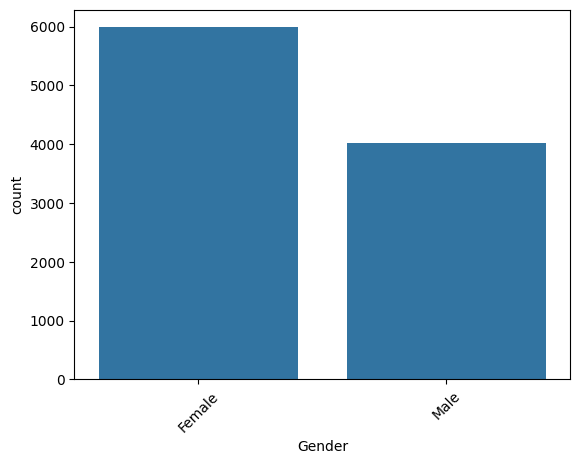

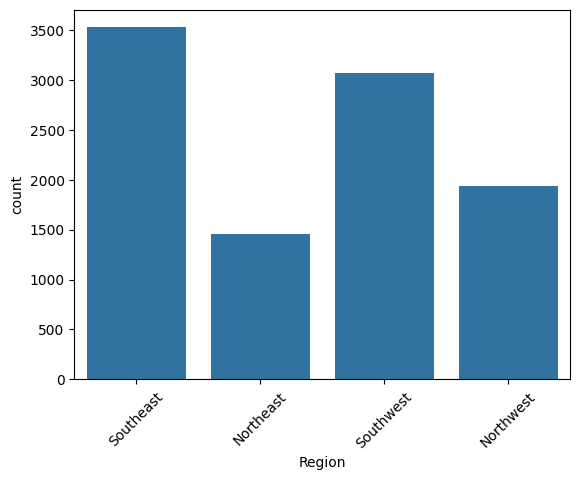

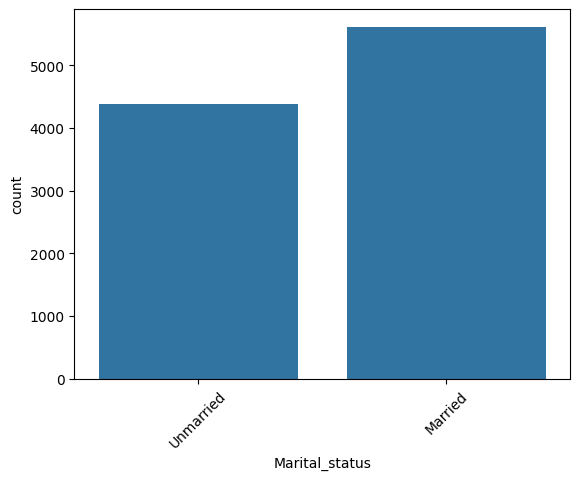

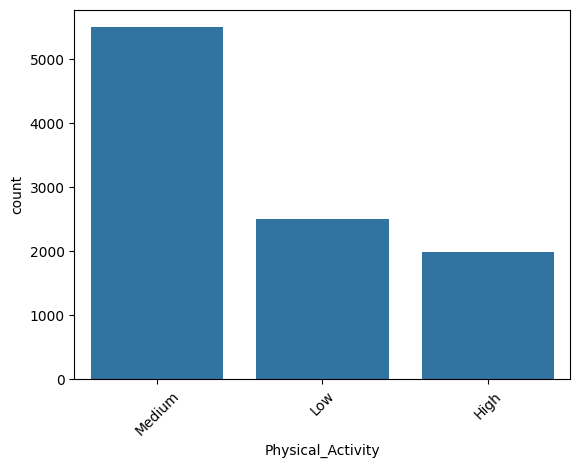

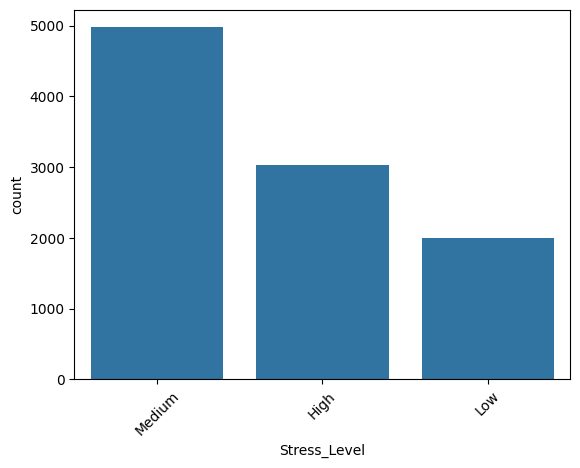

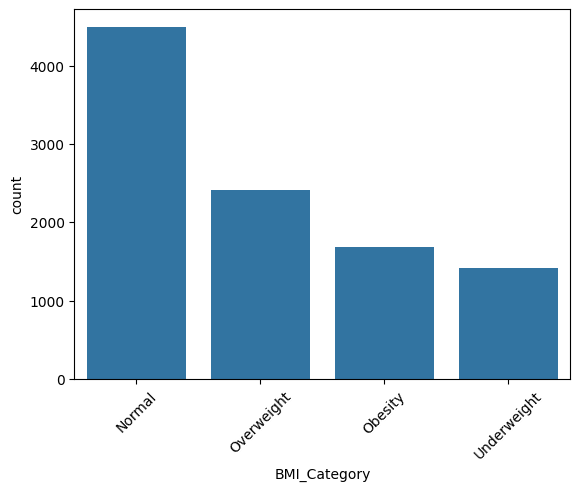

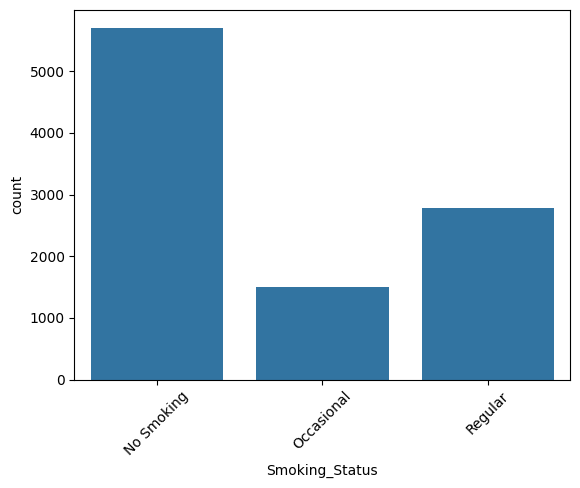

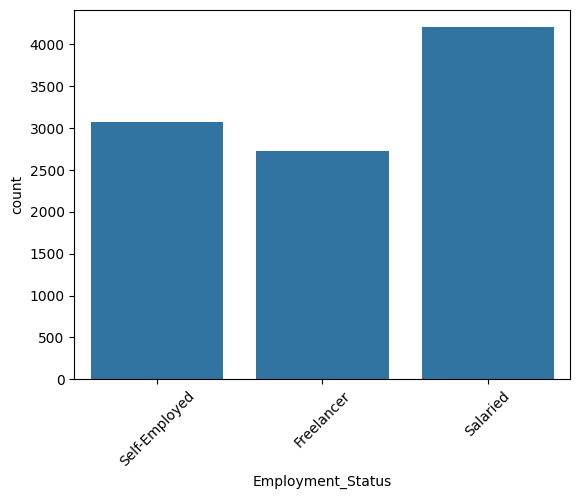

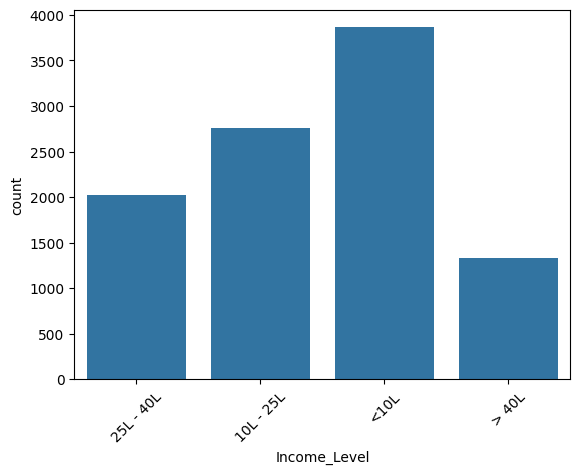

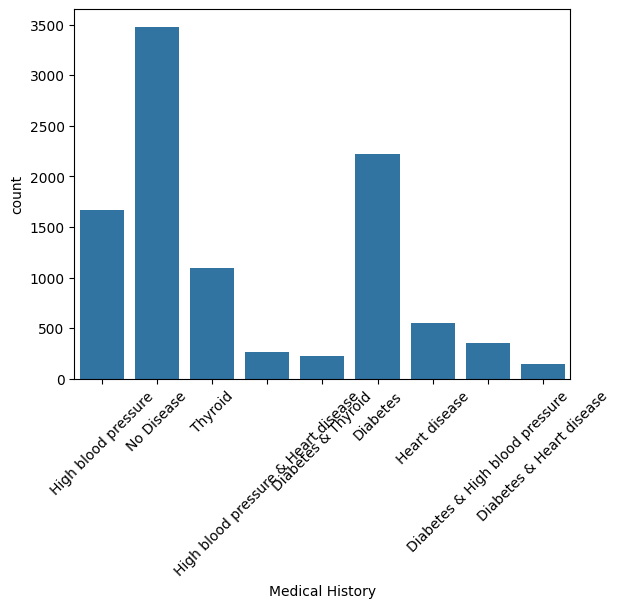

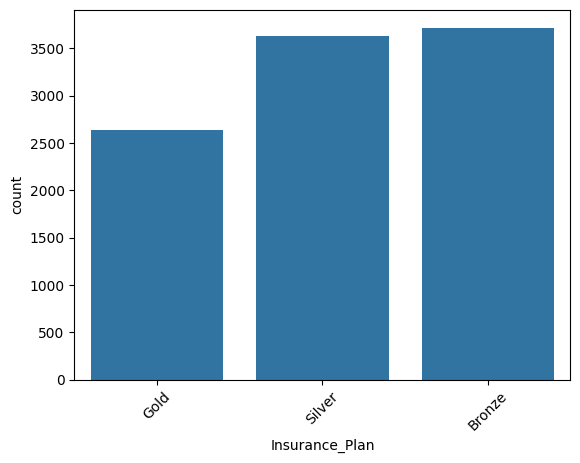

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Numerical 
df.hist(figsize=(12,10))
plt.show()

# Categorical 
for col in df.select_dtypes(include='object'):
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.show()

# Bivariate Analysis
Check relationships with target (premium)

<Axes: xlabel='Age', ylabel='Annual_Premium_Amount'>

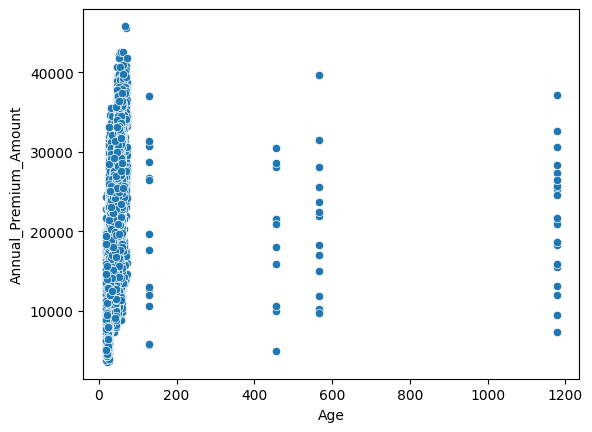

In [17]:
sns.scatterplot(x='Age',y='Annual_Premium_Amount',data=df)

<Axes: xlabel='Gender', ylabel='Annual_Premium_Amount'>

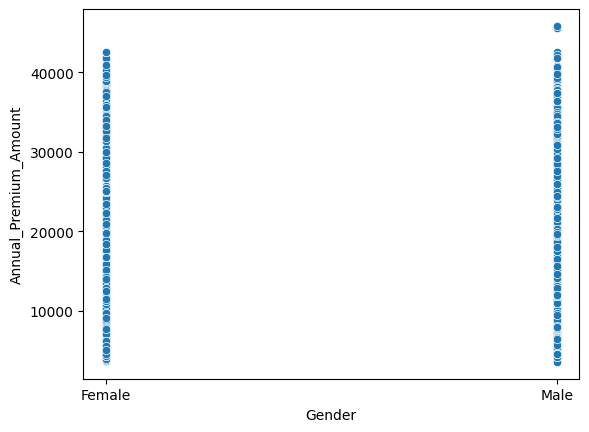

In [16]:
sns.scatterplot(x='Gender',y='Annual_Premium_Amount',data=df)

# Data Cleaning
- Formatting all the column names in the dataframe in uniform format
- Currently the dataset has:
      - Mixed formats (`CamelCase`, spaces, underscores)
      - Inconsistent naming (`Number Of Dependents`, `Medical History`)
Standardise all the column names everything to **snake_case** (`word1_word2`)

In [22]:
df.columns = (
    df.columns
    .str.strip()                      # remove extra spaces
    .str.lower()                      # convert to lowercase
    .str.replace(" ", "_")            # replace spaces with _
    .str.replace(r"[^\w]", "_", regex=True)  # remove special chars
)

In [23]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'physical_activity',
       'stress_level', 'number_of_dependants', 'bmi_category',
       'smoking_status', 'employment_status', 'income_level', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount'],
      dtype='str')

In [24]:
df.head()

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


In [25]:
#Renaming long column names to shorter ones in order to make it easy for ML
df.rename(columns={
    'number_of_dependants': 'dependants',
    'annual_premium_amount': 'premium'
}, inplace=True)

In [26]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'physical_activity',
       'stress_level', 'dependants', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'income_lakhs', 'medical_history',
       'insurance_plan', 'premium'],
      dtype='str')

In [27]:
df.head()

,age,gender,region,marital_status,physical_activity,stress_level,dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,premium
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


# Column By Column Analysis
Column wise analysis will be done in order to handle outliers , and to classify the string values to numeric type and also to check if any null or nan values are there but to handle them.

In [28]:
#1. age column
df['age'].describe()

count    10000.000000
mean        41.316300
std         57.971661
min         18.000000
25%         24.000000
50%         37.000000
75%         50.000000
max       1178.000000
Name: age, dtype: float64

In [32]:
#Check how many records in column age have values greater than 100
df[df['age'] > 100].shape

(58, 15)

In [33]:
#Since the dataset has 10000 records, only 58 related to age does not have good quality data hence we shall drop those 58 records
df = df[df['age']<=100]

In [35]:
df['age'].describe()

count    9942.000000
mean       37.750251
std        13.979445
min        18.000000
25%        24.000000
50%        37.000000
75%        50.000000
max        72.000000
Name: age, dtype: float64

In [36]:
#2. Gender Column Analysis
df['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [37]:
df['gender'].value_counts()

gender
Female    5951
Male      3991
Name: count, dtype: int64

In [38]:
df['gender'].isnull().sum()

np.int64(0)

In [39]:
#Convert string Female and Male to integer values as 0 and 1
df['gender'] = df['gender'].map({'Female':0,'Male':1})

In [40]:
df['gender'].unique()

array([0, 1])

In [41]:
df['gender'].value_counts()

gender
0    5951
1    3991
Name: count, dtype: int64

In [42]:
#3. Region Column Analysis
df['region'].unique()

<StringArray>
['Southeast', 'Northeast', 'Southwest', 'Northwest']
Length: 4, dtype: str

In [43]:
df['region'].value_counts()

region
Southeast    3507
Southwest    3054
Northwest    1932
Northeast    1449
Name: count, dtype: int64

In [44]:
df['region'].isnull().sum()

np.int64(0)

In [45]:
#Apply One Hot Encoding
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [49]:
df.head()

,age,gender,marital_status,physical_activity,stress_level,dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,premium,region_Northwest,region_Southeast,region_Southwest
0,56,0,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944,False,True,False
1,38,0,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108,False,False,False
2,18,0,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459,False,False,True
3,55,1,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685,False,False,False
4,22,1,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984,False,True,False


In [50]:
#4. Marital Status Column Analysis
df['marital_status'].unique()

<StringArray>
['Unmarried', 'Married']
Length: 2, dtype: str

In [51]:
df['marital_status'].value_counts()

marital_status
Married      5587
Unmarried    4355
Name: count, dtype: int64

In [52]:
df['marital_status'].isnull().sum()

np.int64(0)

In [53]:
#Binary Encoding map
df['marital_status'] = df['marital_status'].map({'Unmarried':0,'Married':1})

In [54]:
df['marital_status'].head()

0    0
1    1
2    0
3    1
4    0
Name: marital_status, dtype: int64

In [55]:
#5. Physical Activty Column Analysis
df['physical_activity'].unique()

<StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str

In [56]:
df['physical_activity'].value_counts()

physical_activity
Medium    5459
Low       2501
High      1982
Name: count, dtype: int64

In [57]:
df['physical_activity'].isnull().sum()

np.int64(0)

In [58]:
#6. Stress Level Column Analysis
df['stress_level'].unique()

<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str

In [59]:
df['stress_level'].value_counts()

stress_level
Medium    4950
High      3004
Low       1988
Name: count, dtype: int64

In [60]:
df['stress_level'].isnull().sum()

np.int64(0)

# Business Requirement - Develop `life_style_risk_score`

`life_style_risk_score` is being added as part of the business requirement which follows the given business rule.  
Combination of `physical_activity` and `stress_level`.

## Business Logic for `life_style_risk_score`

### Physical Activity

- High Activity → 0
- Medium → 1
- Low → 4

### Stress Level

- High → 4
- Medium → 1
- Low → 0

In [62]:
activity_map = {
    'High': 0,
    'Medium': 1,
    'Low': 4
}

stress_map = {
    'High': 4,
    'Medium': 1,
    'Low': 0
}

In [63]:
df['life_style_risk_score'] = (
    df['physical_activity'].map(activity_map) +
    df['stress_level'].map(stress_map)
)

In [64]:
df[['physical_activity', 'stress_level', 'life_style_risk_score']].head()

,physical_activity,stress_level,life_style_risk_score
0,Medium,Medium,2
1,Low,High,8
2,Medium,High,5
3,High,Medium,1
4,Medium,High,5


In [65]:
df.drop(['physical_activity', 'stress_level'], axis=1, inplace=True)

In [66]:
df.head()

,age,gender,marital_status,dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,premium,region_Northwest,region_Southeast,region_Southwest,life_style_risk_score
0,56,0,0,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944,False,True,False,2
1,38,0,1,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108,False,False,False,8
2,18,0,0,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459,False,False,True,5
3,55,1,1,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685,False,False,False,1
4,22,1,0,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984,False,True,False,5


In [68]:
#7. Dependants column analysis
df['dependants'].unique()

array([  2,   5,   0,   3,   1,   4, 456,  78, 230])

In [69]:
df['dependants'].value_counts()

dependants
0      2614
3      2433
2      1911
1      1428
4      1097
5       412
456      19
78       15
230      13
Name: count, dtype: int64

In [70]:
df['dependants'].isnull().sum()

np.int64(0)

In [71]:
#Dependants cannot be more than 5 hence removing records which have more than this

In [72]:
df = df[df['dependants'] <= 5]

In [74]:
df['dependants'].unique()

array([2, 5, 0, 3, 1, 4])

In [75]:
df['dependants'].value_counts()

dependants
0    2614
3    2433
2    1911
1    1428
4    1097
5     412
Name: count, dtype: int64

In [76]:
#8. bmi_category column analysis
df['bmi_category'].unique()

<StringArray>
['Normal', 'Overweight', 'Obesity', 'Underweight']
Length: 4, dtype: str

In [77]:
df['bmi_category'].value_counts()

bmi_category
Normal         4449
Overweight     2379
Obesity        1661
Underweight    1406
Name: count, dtype: int64

In [78]:
df['bmi_category'].isnull().sum()

np.int64(0)

In [79]:
df['bmi_category'] = df['bmi_category'].map({
    'Underweight': 0,
    'Normal': 1,
    'Overweight': 2,
    'Obesity': 3
})

In [80]:
df['bmi_category'].unique()

array([1, 2, 3, 0])

In [81]:
df.head()

,age,gender,marital_status,dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,premium,region_Northwest,region_Southeast,region_Southwest,life_style_risk_score
0,56,0,0,2,1,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944,False,True,False,2
1,38,0,1,5,2,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108,False,False,False,8
2,18,0,0,0,1,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459,False,False,True,5
3,55,1,1,3,2,Occasional,Salaried,<10L,9,Thyroid,Silver,21685,False,False,False,1
4,22,1,0,2,1,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984,False,True,False,5


In [83]:
#9. Smoking Status Column Analysis
df['smoking_status'].unique()

<StringArray>
['No Smoking', 'Occasional', 'Regular', nan]
Length: 4, dtype: str

In [84]:
df['smoking_status'].value_counts()

smoking_status
No Smoking    5645
Regular       2756
Occasional    1485
Name: count, dtype: int64

In [85]:
df['smoking_status'].isnull().sum()

np.int64(9)

In [87]:
#Handle missing values and fill it with mode
df['smoking_status'] = df['smoking_status'].fillna(df['smoking_status'].mode()[0])

In [89]:
#Encoding
df['smoking_status'] = df['smoking_status'].map({
    'No Smoking': 0,
    'Occasional': 1,
    'Regular': 2
})

In [90]:
df['smoking_status'].unique()

array([0, 1, 2])

In [91]:
df.head()

,age,gender,marital_status,dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,premium,region_Northwest,region_Southeast,region_Southwest,life_style_risk_score
0,56,0,0,2,1,0,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944,False,True,False,2
1,38,0,1,5,2,1,Freelancer,10L - 25L,10,No Disease,Silver,21108,False,False,False,8
2,18,0,0,0,1,0,Freelancer,<10L,9,No Disease,Bronze,8459,False,False,True,5
3,55,1,1,3,2,1,Salaried,<10L,9,Thyroid,Silver,21685,False,False,False,1
4,22,1,0,2,1,2,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984,False,True,False,5


In [92]:
df['smoking_status'].isnull().sum()

np.int64(0)

In [93]:
#10. Employment Status Column Analysis
df['employment_status'].unique()

<StringArray>
['Self-Employed', 'Freelancer', 'Salaried', nan]
Length: 4, dtype: str

In [94]:
df['employment_status'].value_counts()

employment_status
Salaried         4151
Self-Employed    3049
Freelancer       2688
Name: count, dtype: int64

In [95]:
df['employment_status'].isnull().sum()

np.int64(7)

In [96]:
#Fill missing values with mode 
df['employment_status'] = df['employment_status'].fillna(df['employment_status'].mode()[0])

In [97]:
df = pd.get_dummies(df, columns=['employment_status'], drop_first=True)

In [98]:
df.head()

,age,gender,marital_status,dependants,bmi_category,smoking_status,income_level,income_lakhs,medical_history,insurance_plan,premium,region_Northwest,region_Southeast,region_Southwest,life_style_risk_score,employment_status_Salaried,employment_status_Self-Employed
0,56,0,0,2,1,0,25L - 40L,37,High blood pressure,Gold,27944,False,True,False,2,False,True
1,38,0,1,5,2,1,10L - 25L,10,No Disease,Silver,21108,False,False,False,8,False,False
2,18,0,0,0,1,0,<10L,9,No Disease,Bronze,8459,False,False,True,5,False,False
3,55,1,1,3,2,1,<10L,9,Thyroid,Silver,21685,False,False,False,1,True,False
4,22,1,0,2,1,2,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984,False,True,False,5,False,True


In [99]:
#11. Income Lakhs Column Analysis
df['income_lakhs'].describe()

count    9895.000000
mean       23.368772
std        32.405306
min         1.000000
25%         6.000000
50%        16.000000
75%        31.000000
max       960.000000
Name: income_lakhs, dtype: float64

In [100]:
df['income_lakhs'].isnull().sum()

np.int64(0)

In [104]:
#Validate outliers based on the result 
len(df[df['income_lakhs'] > 100])

10

<Axes: xlabel='income_lakhs'>

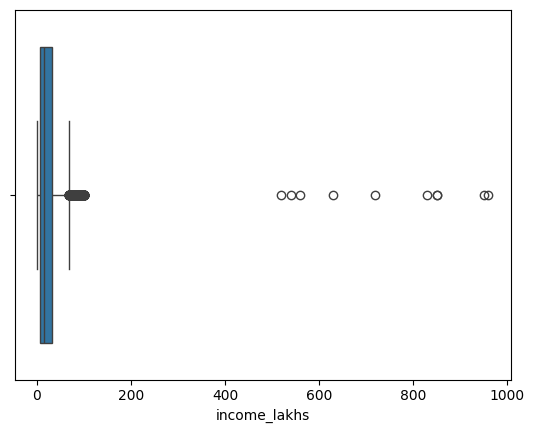

In [105]:
#Visualise income level to see the skewness
import seaborn as sns
sns.boxplot(x=df['income_lakhs'])

In [106]:
#Very few outliers exist in terms of income_lakhs hence deciding to remove those records
df = df[df['income_lakhs'] <= 100]

In [107]:
df.head()

,age,gender,marital_status,dependants,bmi_category,smoking_status,income_level,income_lakhs,medical_history,insurance_plan,premium,region_Northwest,region_Southeast,region_Southwest,life_style_risk_score,employment_status_Salaried,employment_status_Self-Employed
0,56,0,0,2,1,0,25L - 40L,37,High blood pressure,Gold,27944,False,True,False,2,False,True
1,38,0,1,5,2,1,10L - 25L,10,No Disease,Silver,21108,False,False,False,8,False,False
2,18,0,0,0,1,0,<10L,9,No Disease,Bronze,8459,False,False,True,5,False,False
3,55,1,1,3,2,1,<10L,9,Thyroid,Silver,21685,False,False,False,1,True,False
4,22,1,0,2,1,2,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984,False,True,False,5,False,True


In [108]:
df['income_lakhs'].describe()

count    9885.000000
mean       22.642792
std        22.438552
min         1.000000
25%         6.000000
50%        16.000000
75%        31.000000
max       100.000000
Name: income_lakhs, dtype: float64

<Axes: xlabel='income_lakhs'>

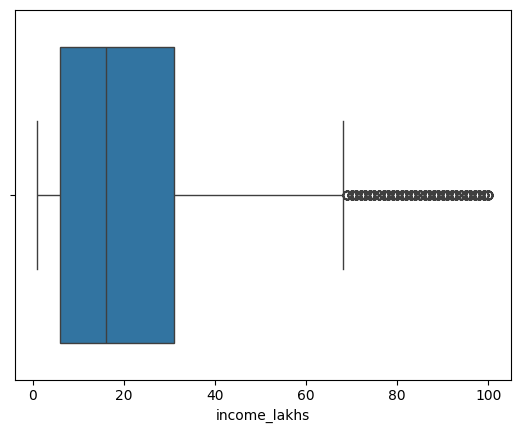

In [109]:
import seaborn as sns
sns.boxplot(x=df['income_lakhs'])

In [110]:
#12. Medical History column analysis
df['medical_history'].unique()

<StringArray>
[                'High blood pressure',                          'No Disease',
                             'Thyroid', 'High blood pressure & Heart disease',
                  'Diabetes & Thyroid',                            'Diabetes',
                       'Heart disease',      'Diabetes & High blood pressure',
            'Diabetes & Heart disease']
Length: 9, dtype: str

In [111]:
df['medical_history'].value_counts()

medical_history
No Disease                             3432
Diabetes                               2192
High blood pressure                    1653
Thyroid                                1081
Heart disease                           549
Diabetes & High blood pressure          349
High blood pressure & Heart disease     264
Diabetes & Thyroid                      222
Diabetes & Heart disease                143
Name: count, dtype: int64

In [112]:
df['medical_history'].isnull().sum()

np.int64(0)

In [113]:
#This dataset needs better handling so multi label feature engineering is required
df['diabetes'] = df['medical_history'].apply(lambda x: 1 if 'Diabetes' in x else 0)
df['high_bp'] = df['medical_history'].apply(lambda x: 1 if 'High blood pressure' in x else 0)
df['heart_disease'] = df['medical_history'].apply(lambda x: 1 if 'Heart disease' in x else 0)
df['thyroid'] = df['medical_history'].apply(lambda x: 1 if 'Thyroid' in x else 0)

In [114]:
df[['medical_history', 'diabetes', 'high_bp', 'heart_disease', 'thyroid']].head()

,medical_history,diabetes,high_bp,heart_disease,thyroid
0,High blood pressure,0,1,0,0
1,No Disease,0,0,0,0
2,No Disease,0,0,0,0
3,Thyroid,0,0,0,1
4,High blood pressure & Heart disease,0,1,1,0


In [115]:
df.drop('medical_history', axis=1, inplace=True)

In [116]:
df.head()

,age,gender,marital_status,dependants,bmi_category,smoking_status,income_level,income_lakhs,insurance_plan,premium,region_Northwest,region_Southeast,region_Southwest,life_style_risk_score,employment_status_Salaried,employment_status_Self-Employed,diabetes,high_bp,heart_disease,thyroid
0,56,0,0,2,1,0,25L - 40L,37,Gold,27944,False,True,False,2,False,True,0,1,0,0
1,38,0,1,5,2,1,10L - 25L,10,Silver,21108,False,False,False,8,False,False,0,0,0,0
2,18,0,0,0,1,0,<10L,9,Bronze,8459,False,False,True,5,False,False,0,0,0,0
3,55,1,1,3,2,1,<10L,9,Silver,21685,False,False,False,1,True,False,0,0,0,1
4,22,1,0,2,1,2,10L - 25L,13,Bronze,15984,False,True,False,5,False,True,0,1,1,0


In [117]:
df['disease_count'] = (
    df['diabetes'] +
    df['high_bp'] +
    df['heart_disease'] +
    df['thyroid']
)

In [118]:
df.head()

,age,gender,marital_status,dependants,bmi_category,smoking_status,income_level,income_lakhs,insurance_plan,premium,...,region_Southeast,region_Southwest,life_style_risk_score,employment_status_Salaried,employment_status_Self-Employed,diabetes,high_bp,heart_disease,thyroid,disease_count
0,56,0,0,2,1,0,25L - 40L,37,Gold,27944,...,True,False,2,False,True,0,1,0,0,1
1,38,0,1,5,2,1,10L - 25L,10,Silver,21108,...,False,False,8,False,False,0,0,0,0,0
2,18,0,0,0,1,0,<10L,9,Bronze,8459,...,False,True,5,False,False,0,0,0,0,0
3,55,1,1,3,2,1,<10L,9,Silver,21685,...,False,False,1,True,False,0,0,0,1,1
4,22,1,0,2,1,2,10L - 25L,13,Bronze,15984,...,True,False,5,False,True,0,1,1,0,2


In [119]:
#13. Insurance Plan Column Analysis
df['insurance_plan'].unique()

<StringArray>
['Gold', 'Silver', 'Bronze']
Length: 3, dtype: str

In [120]:
df['insurance_plan'].value_counts()

insurance_plan
Bronze    3681
Silver    3587
Gold      2617
Name: count, dtype: int64

In [121]:
df['insurance_plan'].isnull().sum()

np.int64(0)

In [122]:
#Ordinal Encoding
df['insurance_plan'] = df['insurance_plan'].map({
    'Bronze': 0,
    'Silver': 1,
    'Gold': 2
})

In [123]:
df['insurance_plan'].unique()

array([2, 1, 0])

In [124]:
df.head()

,age,gender,marital_status,dependants,bmi_category,smoking_status,income_level,income_lakhs,insurance_plan,premium,...,region_Southeast,region_Southwest,life_style_risk_score,employment_status_Salaried,employment_status_Self-Employed,diabetes,high_bp,heart_disease,thyroid,disease_count
0,56,0,0,2,1,0,25L - 40L,37,2,27944,...,True,False,2,False,True,0,1,0,0,1
1,38,0,1,5,2,1,10L - 25L,10,1,21108,...,False,False,8,False,False,0,0,0,0,0
2,18,0,0,0,1,0,<10L,9,0,8459,...,False,True,5,False,False,0,0,0,0,0
3,55,1,1,3,2,1,<10L,9,1,21685,...,False,False,1,True,False,0,0,0,1,1
4,22,1,0,2,1,2,10L - 25L,13,0,15984,...,True,False,5,False,True,0,1,1,0,2


In [125]:
df.drop('income_level', axis=1, inplace=True)

In [126]:
df.head()

,age,gender,marital_status,dependants,bmi_category,smoking_status,income_lakhs,insurance_plan,premium,region_Northwest,region_Southeast,region_Southwest,life_style_risk_score,employment_status_Salaried,employment_status_Self-Employed,diabetes,high_bp,heart_disease,thyroid,disease_count
0,56,0,0,2,1,0,37,2,27944,False,True,False,2,False,True,0,1,0,0,1
1,38,0,1,5,2,1,10,1,21108,False,False,False,8,False,False,0,0,0,0,0
2,18,0,0,0,1,0,9,0,8459,False,False,True,5,False,False,0,0,0,0,0
3,55,1,1,3,2,1,9,1,21685,False,False,False,1,True,False,0,0,0,1,1
4,22,1,0,2,1,2,13,0,15984,False,True,False,5,False,True,0,1,1,0,2


In [127]:
#14. Premium
df['premium'].describe()

count     9885.000000
mean     19515.087709
std       8896.104232
min       3582.000000
25%      11782.000000
50%      19329.000000
75%      26504.000000
max      45854.000000
Name: premium, dtype: float64

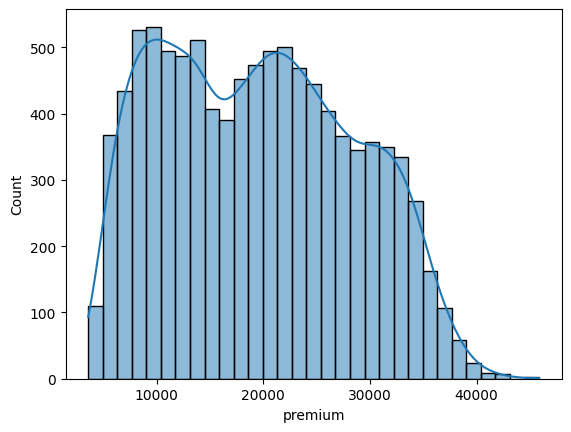

In [128]:
#Visualisation
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['premium'], kde=True)
plt.show()

# Machine Learning starts here!

Now that the EDA and Feature Engineering is done, and the final dataframe is developed, we shall move on to do the test train split and prepare the model.

In [129]:
X = df.drop('premium', axis=1)
y = df['premium']

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [131]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [132]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [133]:
#Predictions
y_pred = model.predict(X_test_scaled)

In [134]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1397.6090626220855
RMSE: 1797.600440589802
R2 Score: 0.9599830724654367


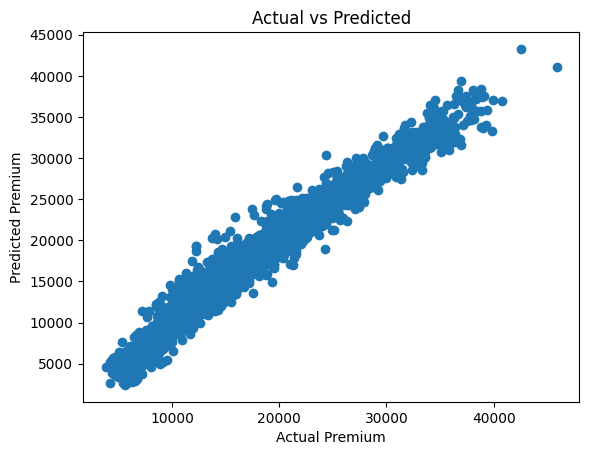

In [135]:
#Visualisation plot
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Premium")
plt.ylabel("Predicted Premium")
plt.title("Actual vs Predicted")
plt.show()

In [136]:
#Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

feature_importance = feature_importance.sort_values(by='Coefficient', key=abs, ascending=False)

print(feature_importance)

                            Feature  Coefficient
7                    insurance_plan  5260.336107
0                               age  2823.616368
4                      bmi_category  1393.723339
5                    smoking_status  1325.750995
11            life_style_risk_score  1289.149636
16                    heart_disease  1076.172532
18                    disease_count   992.117845
2                    marital_status   439.641747
14                         diabetes   271.214498
17                          thyroid   241.912574
15                          high_bp   215.171396
3                        dependants  -203.629947
13  employment_status_Self-Employed   171.034971
6                      income_lakhs  -154.299621
12       employment_status_Salaried    59.847061
9                  region_Southeast    53.838793
1                            gender    31.038905
8                  region_Northwest    23.556189
10                 region_Southwest     0.975397


In [137]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)   # NOTE: no scaling needed

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [138]:
y_pred_rf = rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("RF R2:", r2_score(y_test, y_pred_rf))

RF MAE: 638.4887354577644
RF RMSE: 807.0591811693314
RF R2: 0.9919338150824533


In [139]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [140]:
y_pred_xgb = xgb.predict(X_test)

print("XGB MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGB RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("XGB R2:", r2_score(y_test, y_pred_xgb))

XGB MAE: 569.1321411132812
XGB RMSE: 699.9241253521699
XGB R2: 0.9939332008361816


In [141]:
error_percent = np.abs((y_test - y_pred_xgb) / y_test) * 100

high_error = np.sum(error_percent > 10)
total = len(error_percent)

print("High Error %:", (high_error / total) * 100)

High Error %: 6.87910976226606


In [142]:
xgb_final = XGBRegressor(random_state=42)
xgb_final.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [143]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(xgb_final, f)

In [144]:
feature_columns = X.columns.tolist()

with open('features.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

In [145]:
df.columns

Index(['age', 'gender', 'marital_status', 'dependants', 'bmi_category',
       'smoking_status', 'income_lakhs', 'insurance_plan', 'premium',
       'region_Northwest', 'region_Southeast', 'region_Southwest',
       'life_style_risk_score', 'employment_status_Salaried',
       'employment_status_Self-Employed', 'diabetes', 'high_bp',
       'heart_disease', 'thyroid', 'disease_count'],
      dtype='str')